In [3]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-16/"
slurm_job = 16341727

result_dir = result_dir + date + str(slurm_job) + "/"

run = 0
batches = [1, 6, 7, 10, 12, 14, 15]

envs = [1,2,3]
trials = [1,2,3]

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_58333/2198049941.py:89: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


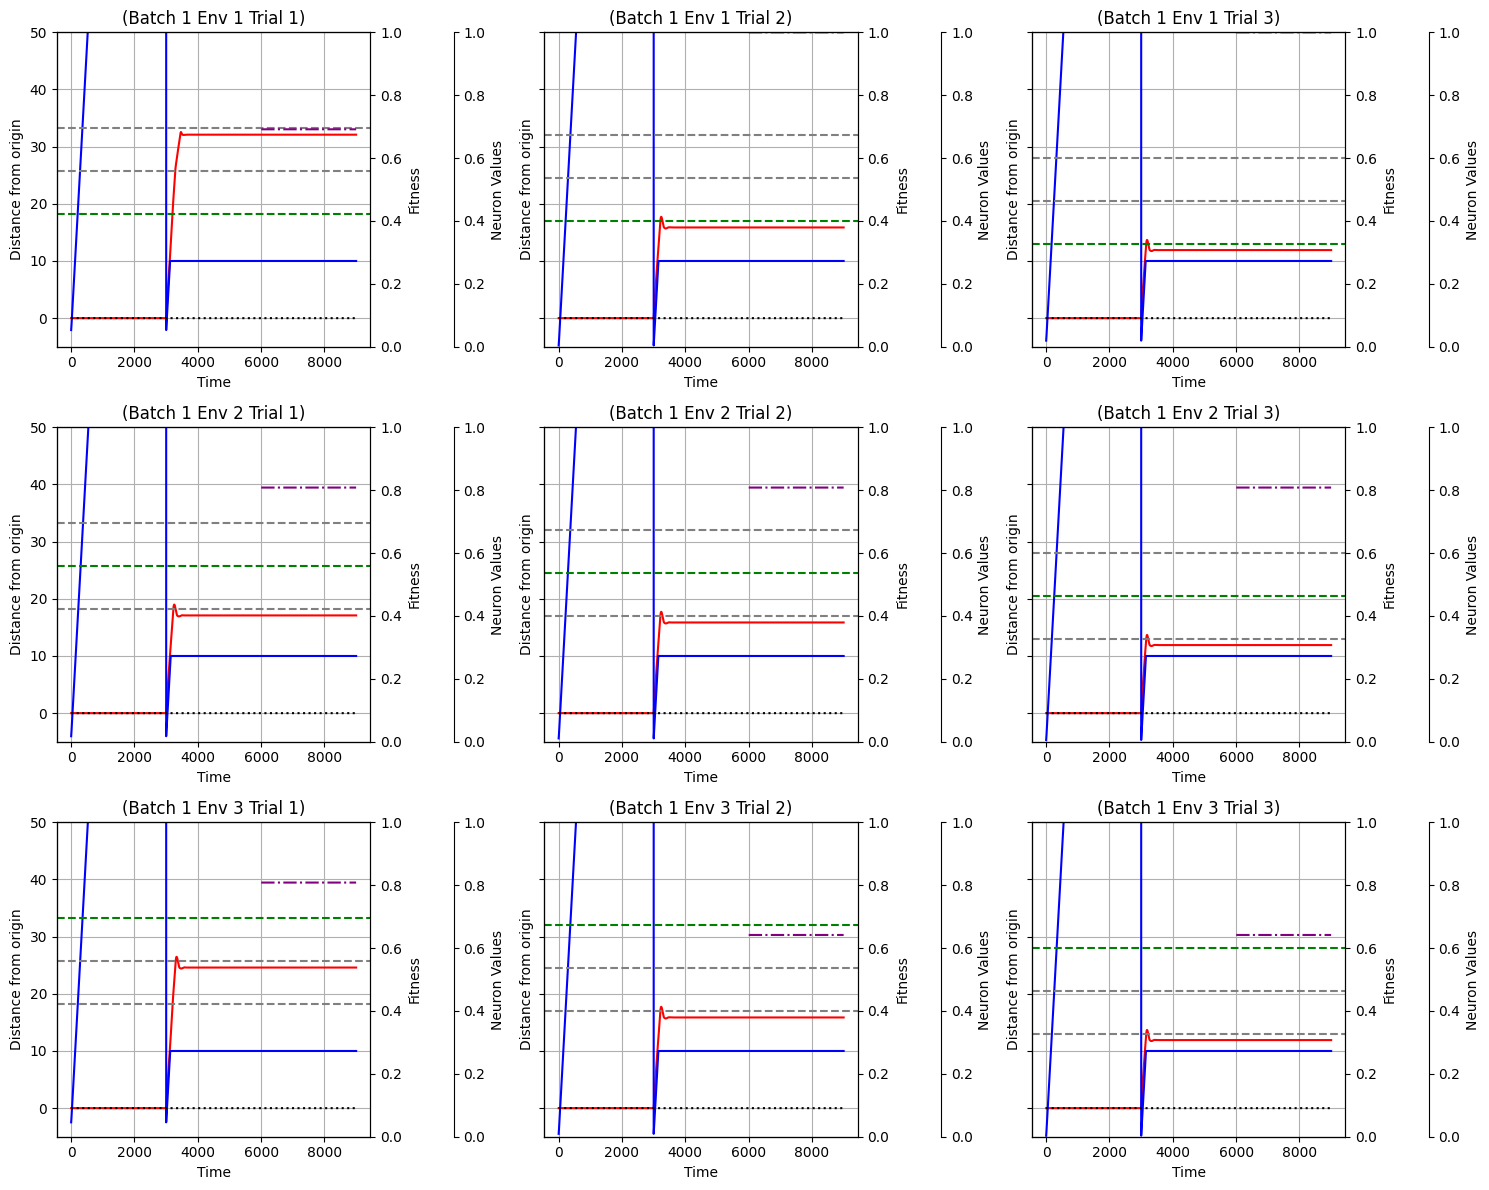

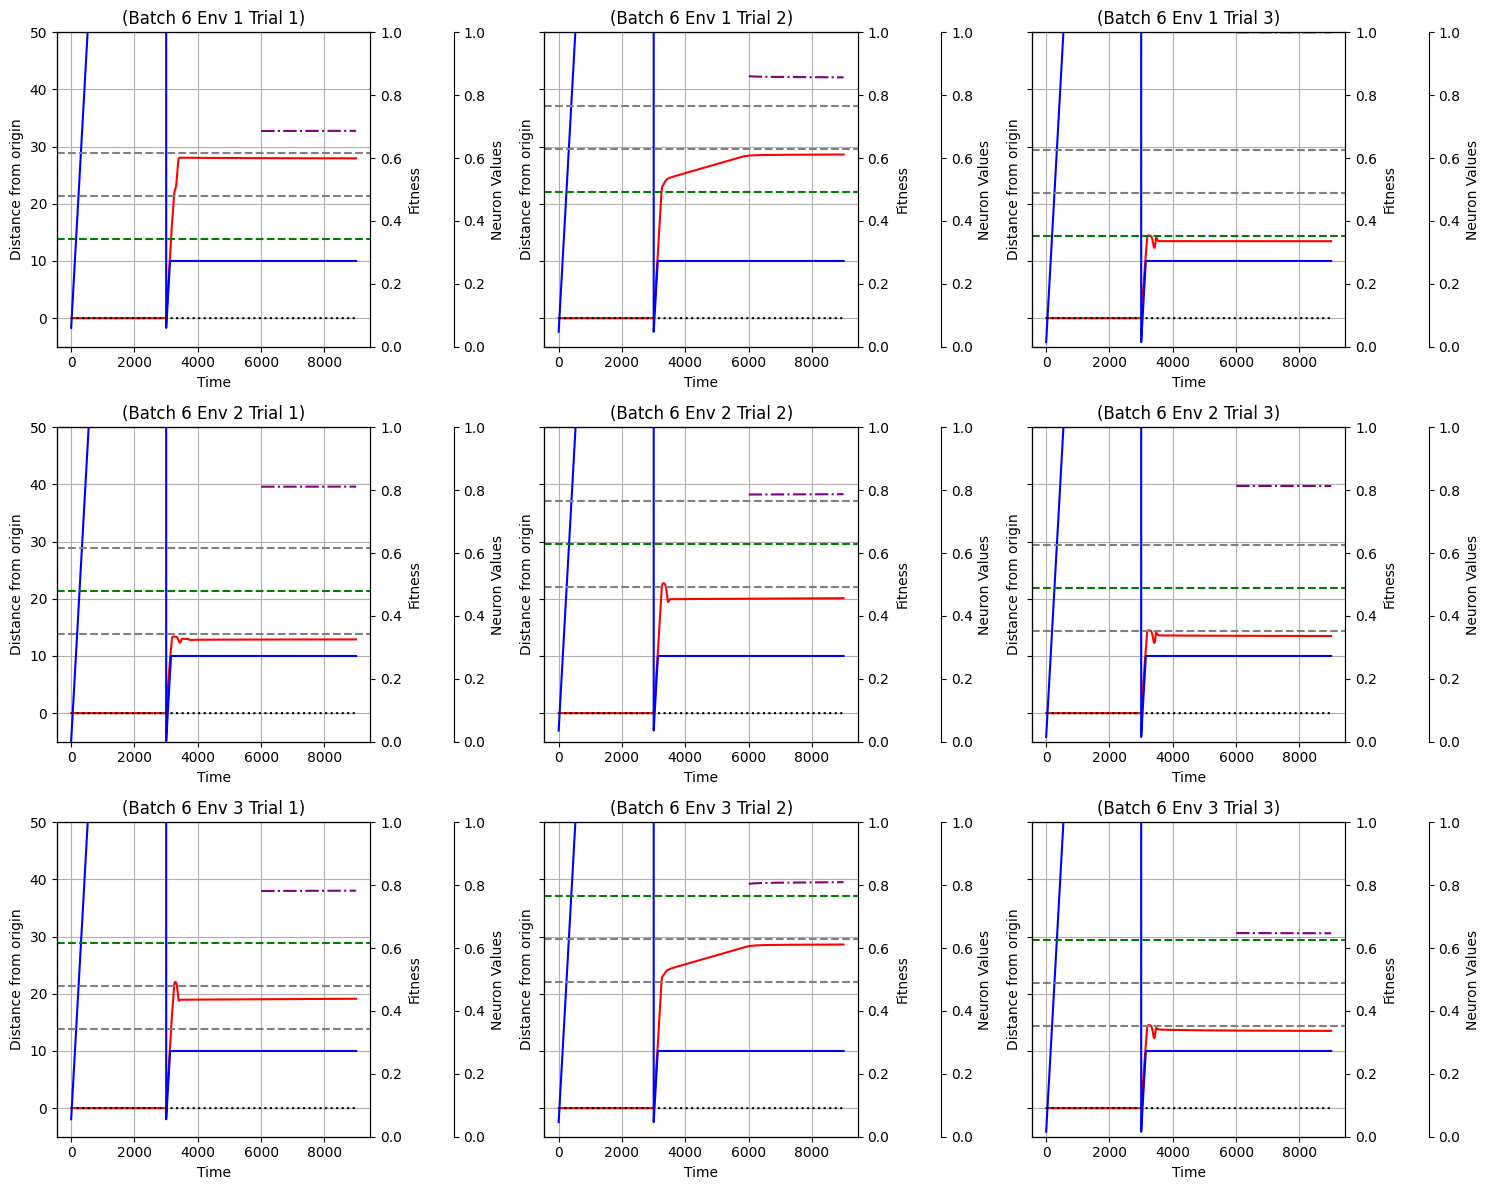

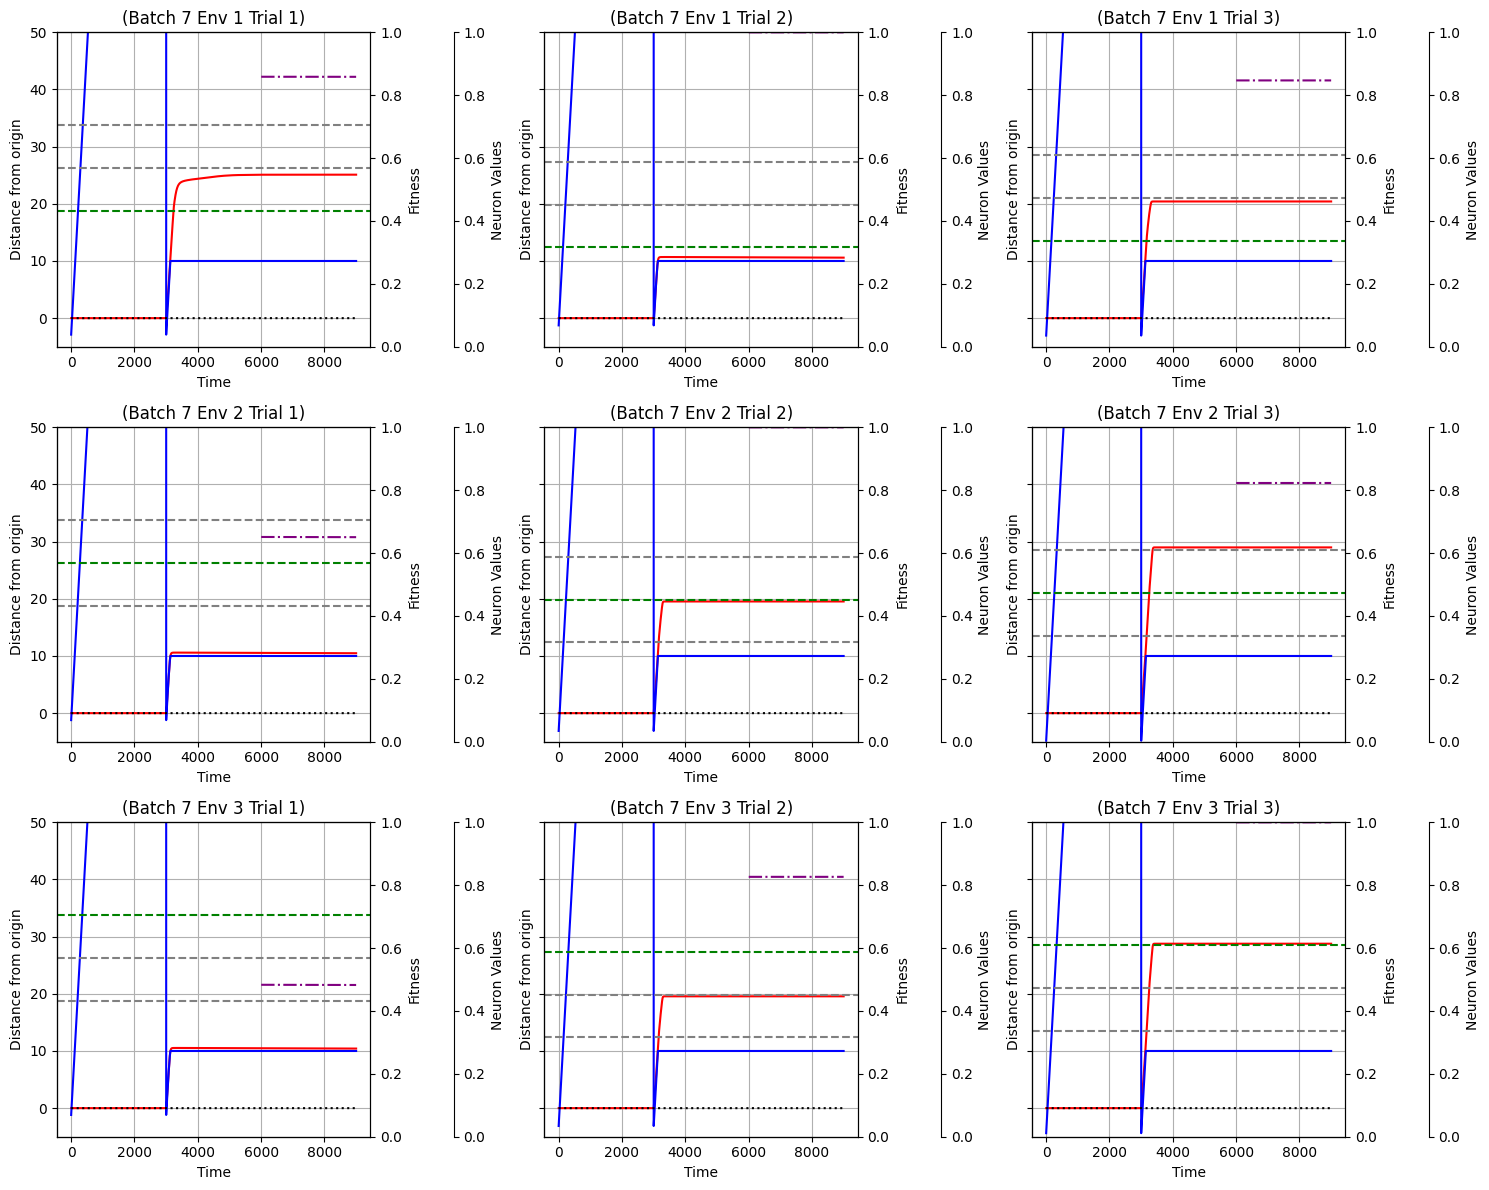

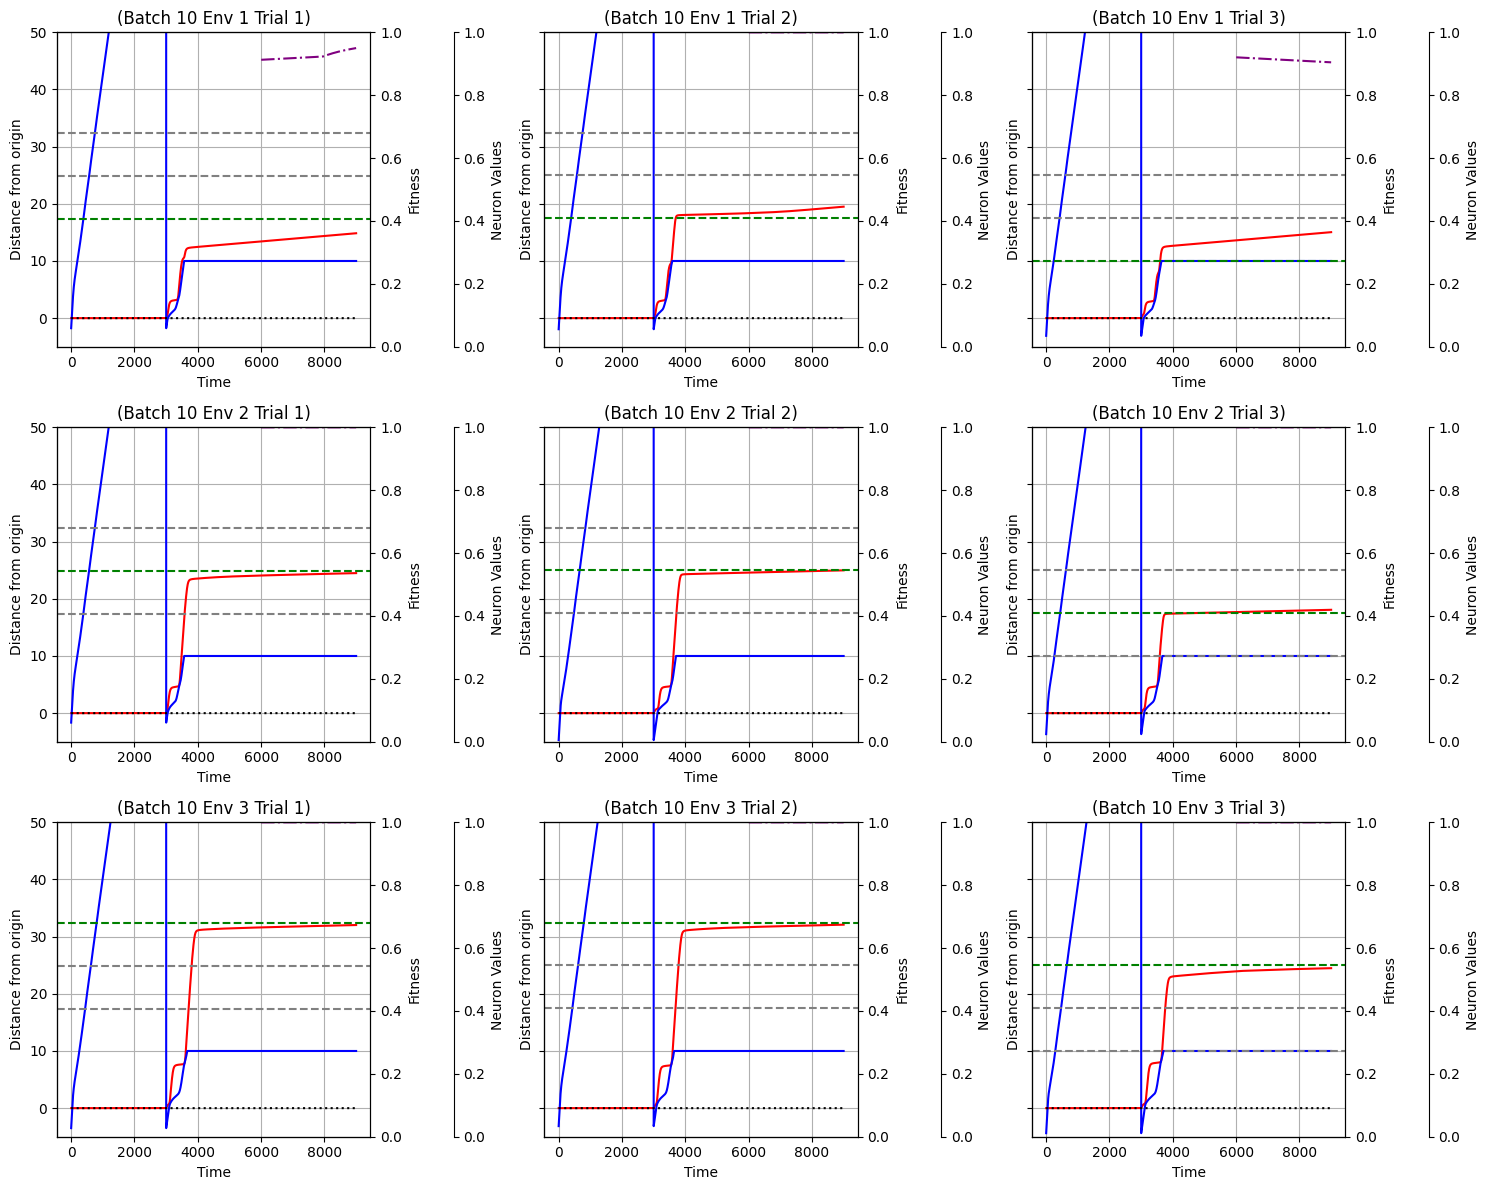

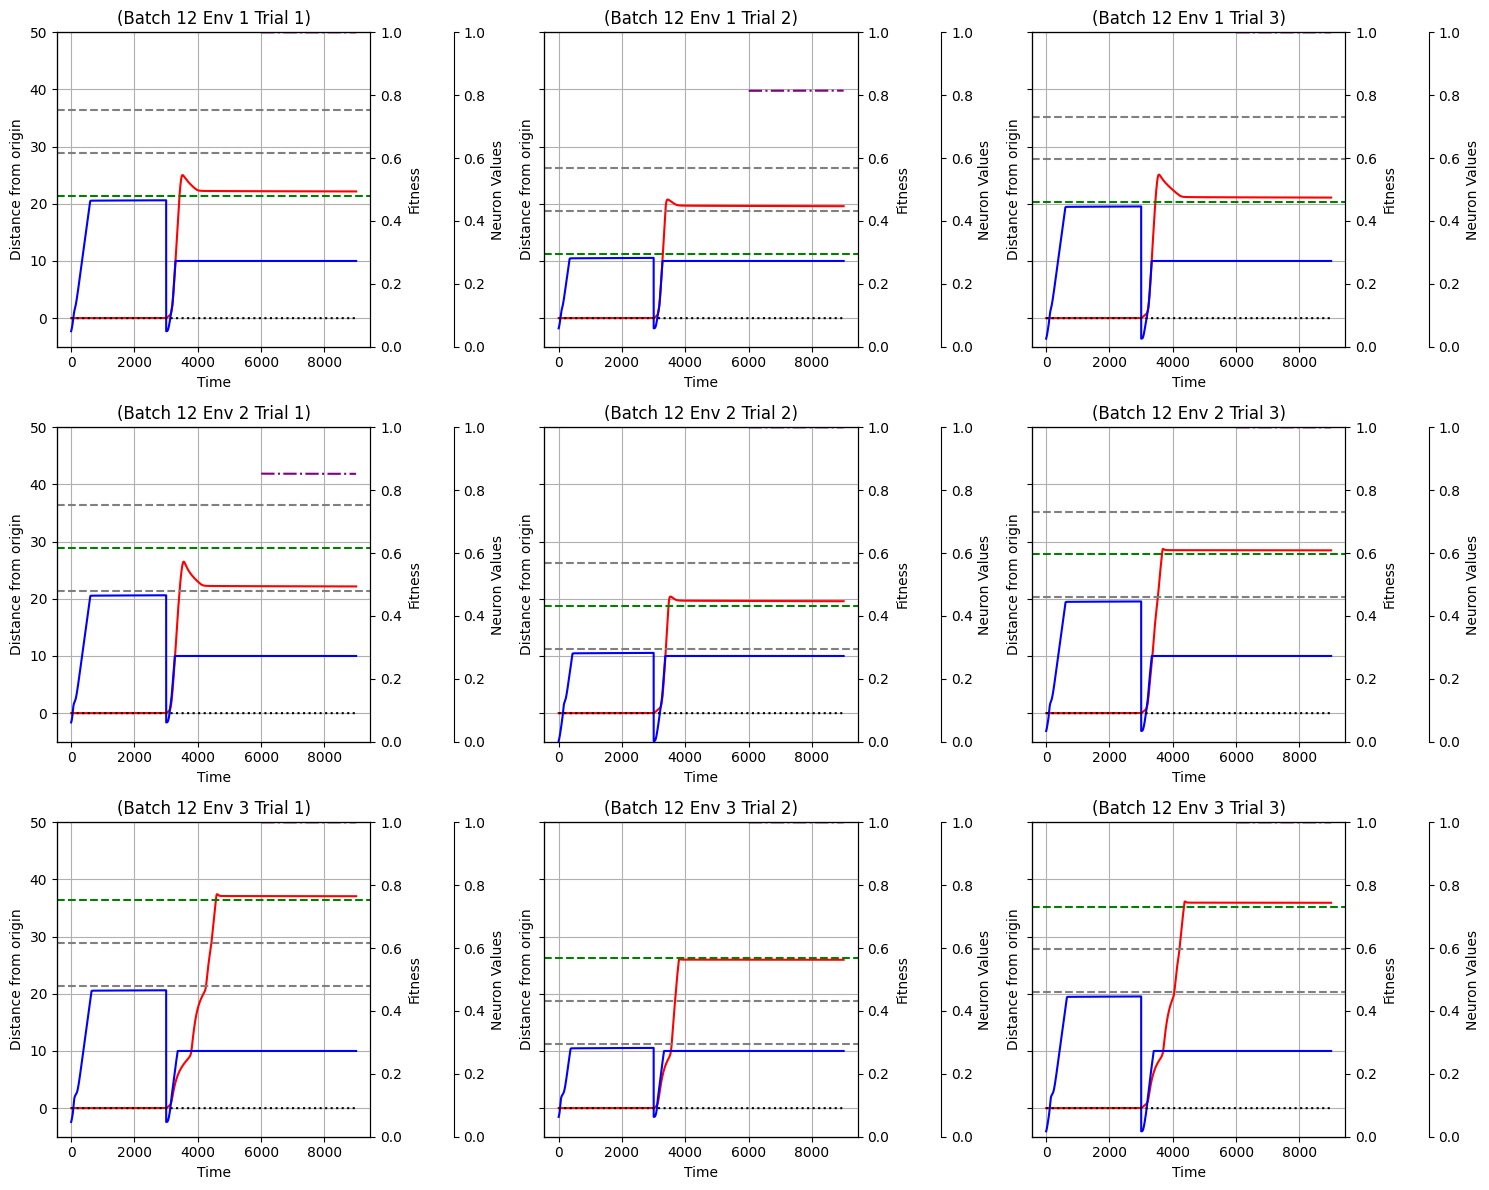

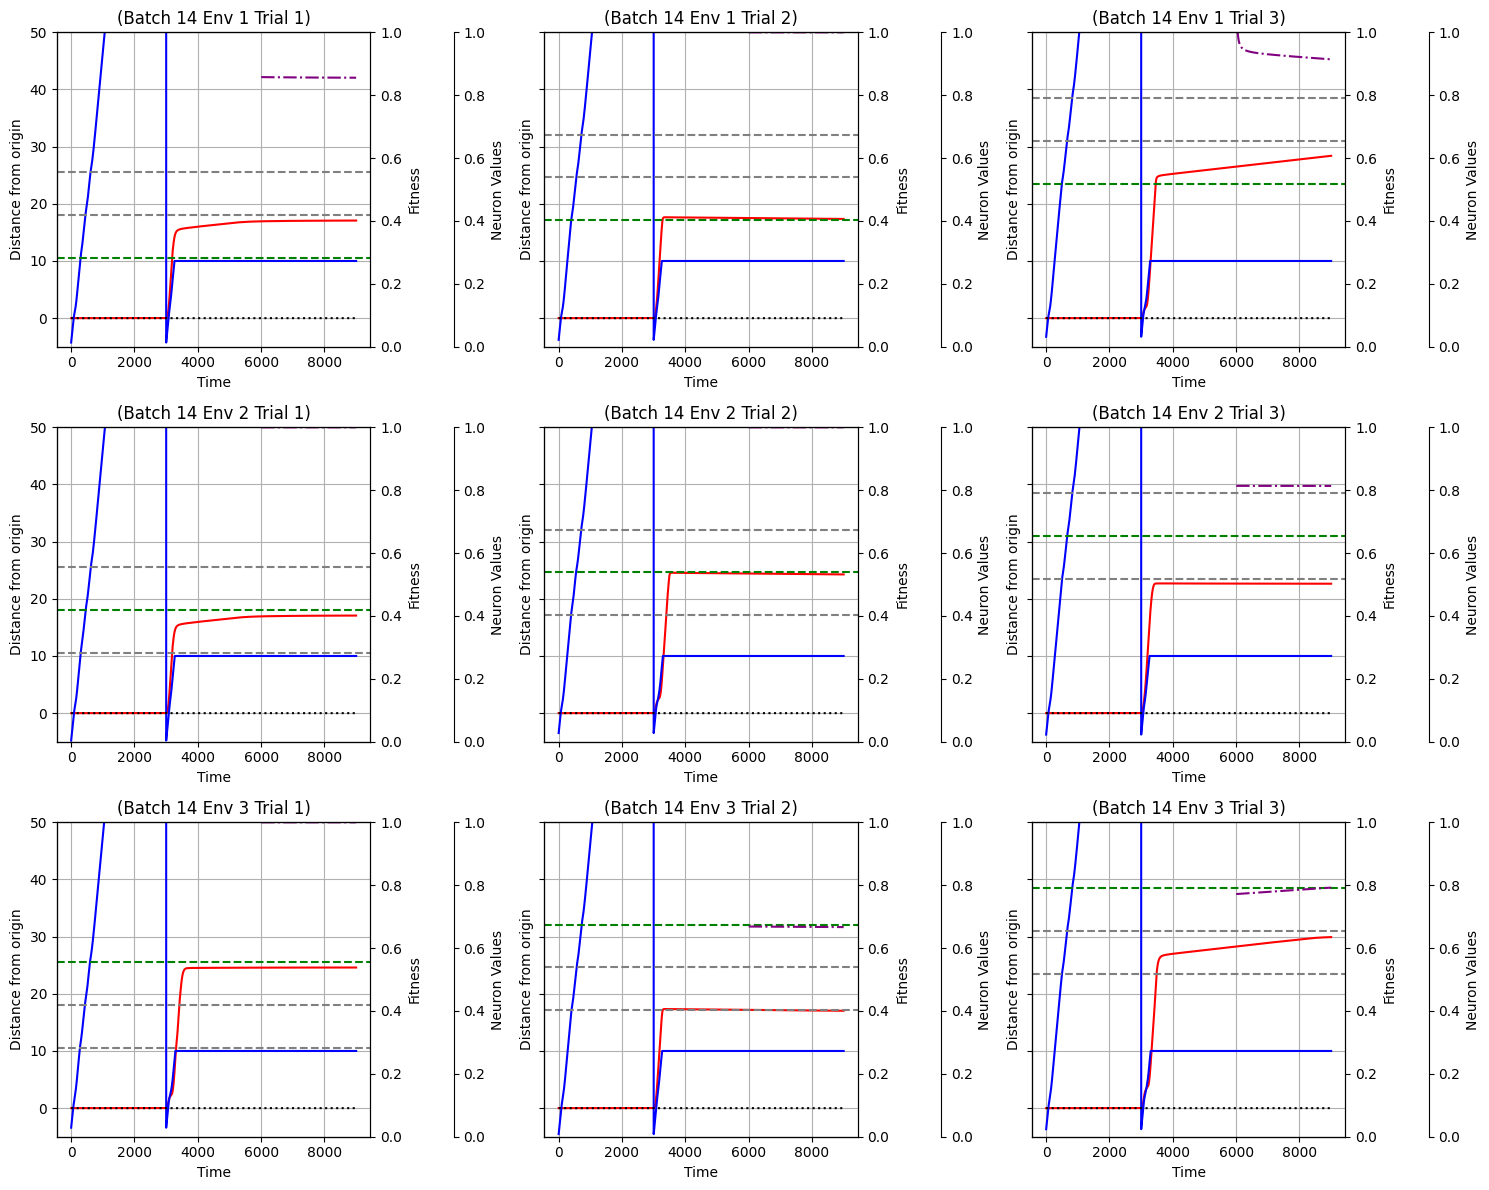

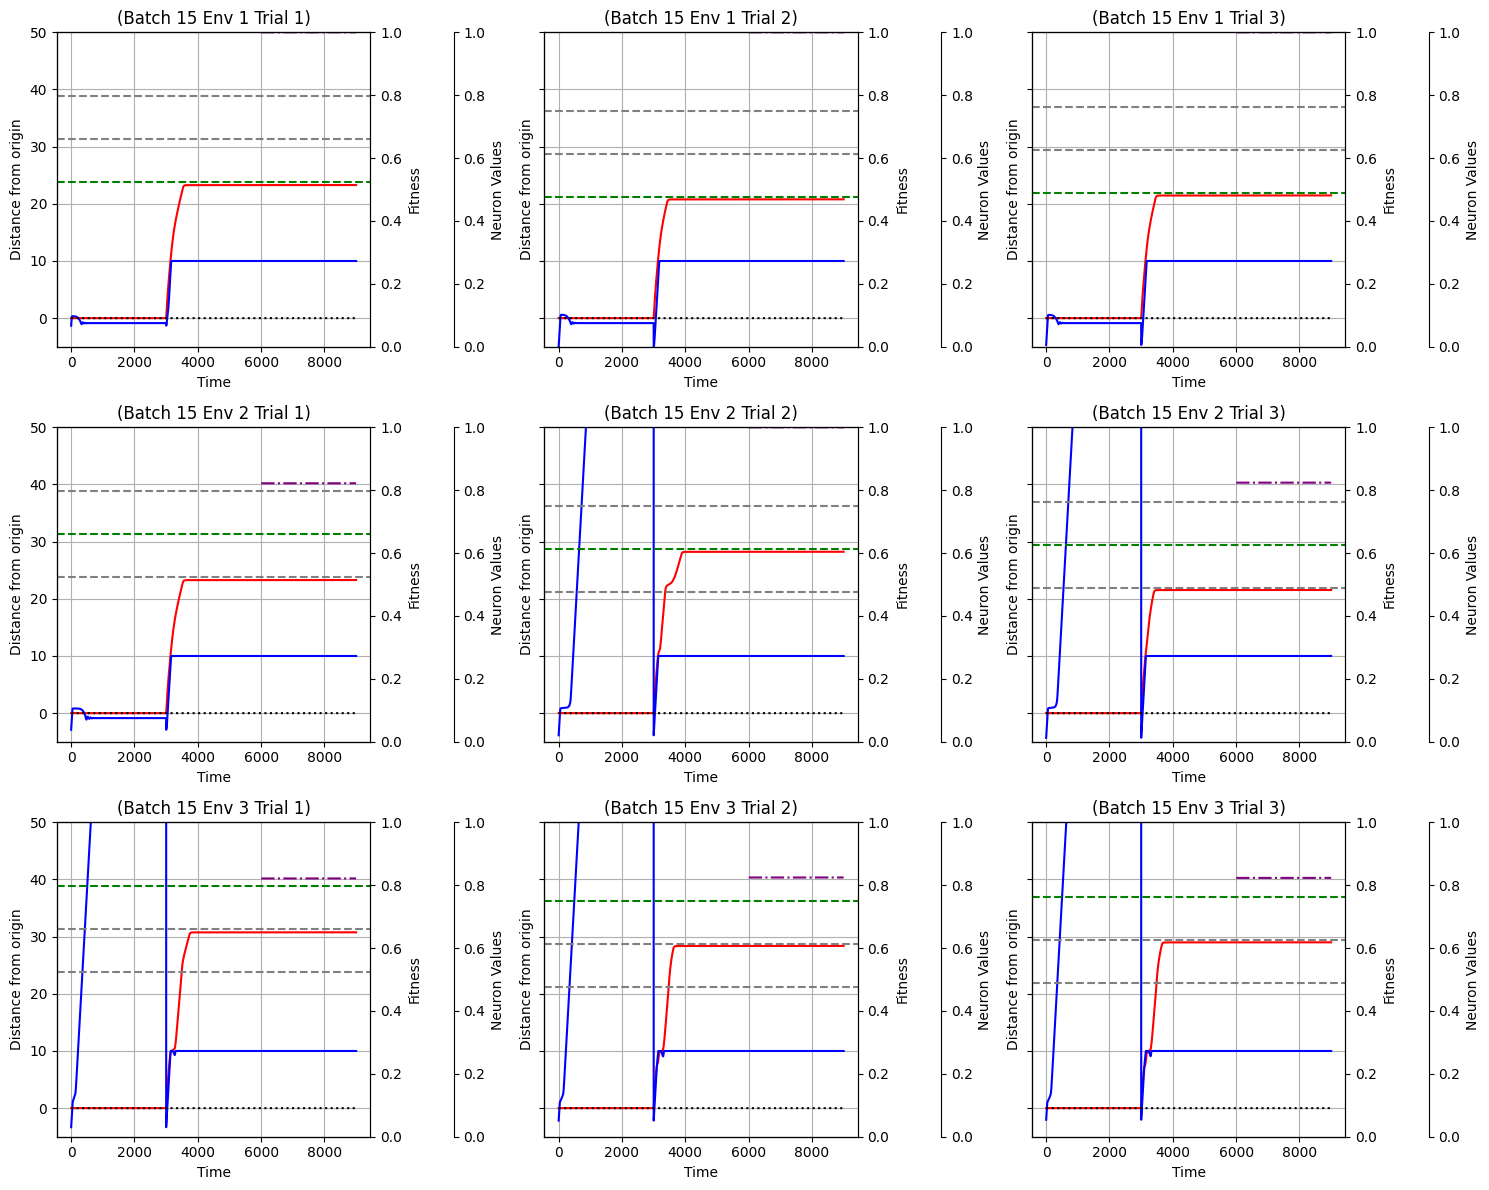

In [4]:
for batch_index, batch in enumerate(batches):
    index = 1
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

    signaller_behaviour_dir = result_dir + f"batch_{batch}/run_{run}/behavior_Signaller_stage1_{run}.dat"
    receiver_behaviour_dir = result_dir + f"batch_{batch}/run_{run}/behavior_Reciever_stage1_{run}.dat"
    fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}.dat"
    landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage3_{run}.dat"

    for trial_index, trial in enumerate(trials):
        for env_index, env in enumerate(envs):

            # graph setup
            ax = axes[env_index, trial_index]
            # fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx() # axis for fitness
            ax3 = ax.twinx() # axis for neural state
            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))
            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)

            
            receiver = read_ith_line(index, receiver_behaviour_dir)
            signaller = read_ith_line(index, signaller_behaviour_dir)
            fitness = read_ith_line(index, fitness_file)
            landmarks = read_ith_line(index, landmark_file)


            # plot the fitness
            stage_length = len(receiver)
            fitness_length = len(fitness)
            fitness_start = stage_length - fitness_length
            fitness_x = range(fitness_start, stage_length)

            ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")

            # plot the receiver
            x_receiver = list(range(0, len(receiver)))
            ax.plot(x_receiver, receiver, label=f"Receiver (Env {env} Trial {trial})", color="red")
            x_signaller = list(range(0, len(signaller)))
            ax.plot(x_signaller, signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")

            # distance between the signaler  and receiver
            distance = np.abs(np.array(x_receiver) - np.array(x_signaller))
            x_distance = list(range(0, len(distance)))
            ax.plot(x_distance, distance, label="Distance", linestyle=":", color="black")
        
            # plot the line marking the landmark position

            # food = landmark[3]

            for i in range(0, 3):
                if (i != env-1):
                    ax.axhline(y=landmarks[i], linestyle="--", label="Landmark", color="grey")
                else:
                    ax.axhline(y=landmarks[i], linestyle="--", label="food position", color="green")


            # # get the neural states
            # neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/neuron1_stage1_0.dat"
            # neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/neuron2_stage1_0.dat"
            # neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/neuron3_stage1_0.dat"
            
            # neuron1 = read_ith_line(index, neural_state_1_file)
            # neuron2 = read_ith_line(index, neural_state_2_file)
            # neuron3 = read_ith_line(index, neural_state_3_file)

            # motor = []

            # for p in range(len(neuron1)):
            #     motor.append(neuron2[p]-neuron1[p])


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            
            fig.tight_layout()
            # fig.legend()
            fig.show()
            index += 1
    # save_current_figure()